In [3]:
import pandas as pd
from pathlib import Path
from math import ceil # arredondar pra cima
#import numpy as np

In [4]:
BASE_DIR = Path("..").resolve()
INFO_PV_FILE = BASE_DIR/'data'/'InfoPV'/'power_station_metadata.csv'
generators = pd.read_csv(INFO_PV_FILE)


In [19]:
t_simulation = 24*60*7 #tempo total de simulação em minutos
npts = ceil(t_simulation/15) #quantidade total de passos da simulação

In [42]:
class PVShapeConverter:
    def __init__(self, npts, generators:pd.DataFrame, PVid:int=1, start:int=96):
        #Tratamento de quais curvas vão ser consideradas    
        if PVid > 51:
            PVid = PVid % 51
        elif PVid <= 0:
            print('WARNING: O número de id de entrada do PV foi', PVid, '\nO número de id de entrada do  PV deve ser igual ou maior que 1, portanto foi atribuído a ele o valor default')
            PVid=1
        
        self.npts = npts
        self.PVid = generators.iloc[PVid-1, 1]
        self.FILE_CSV = self.PVid + '.csv'
        self.CURVES_SOLAR_STATION_FILE = BASE_DIR/'data'/'InfoPV'/'solar_station'/self.FILE_CSV
        self.solar_station_curves = pd.read_csv(self.CURVES_SOLAR_STATION_FILE)
        self.datetime = self.solar_station_curves['datetime'].loc[start:self.npts+start].reset_index(drop=True)
        self.irrad = self.solar_station_curves['poa_irradiance_wm2'].iloc[start:self.npts+start].reset_index(drop=True) #Pega os valores de irradiância incidente no plano dos paineis.
        self.PV = pd.concat([self.datetime, self.irrad], axis=1)

        for i in range(len(self.irrad)):
            if pd.isna(self.irrad.iloc[i]) or self.irrad.iloc[i] < 0:
                self.irrad.iloc[i] = 0
    
    def reamostrar_curva(self, nova_taxa):
        """
        Reamostra uma curva de série temporal (Pandas Series) para qualquer intervalo.
        
        Parâmetros:
        - curva: A variável com os dados (Pandas Series com índice de tempo).
        - nova_taxa: String do Pandas para tempo. Ex: '5s' (5 segundos), '1h' (1 hora), '15min'.
        """
        # 1. resample(nova_taxa): Agrupa os dados no novo intervalo
        # 2. mean(): Se for subamostragem (1h), calcula a média dos pontos. 
        #            Se for sobreamostragem (5s), coloca o valor original no ponto exato e NaN (vazio) no resto.
        # 3. interpolate(method='time'): Se houver buracos (sobreamostragem), preenche ligando os pontos proporcionalmente ao tempo.
        
        self.PVirrad = self.PV.resample(nova_taxa).mean().interpolate(method='time')



In [39]:
conversor = PVShapeConverter(
    npts = npts,
    generators = generators, 
    PVid = 4, 
)




In [46]:
conversor.reamostrar_curva('15min')

AttributeError: 'PVShapeConverter' object has no attribute 'PVirrad'

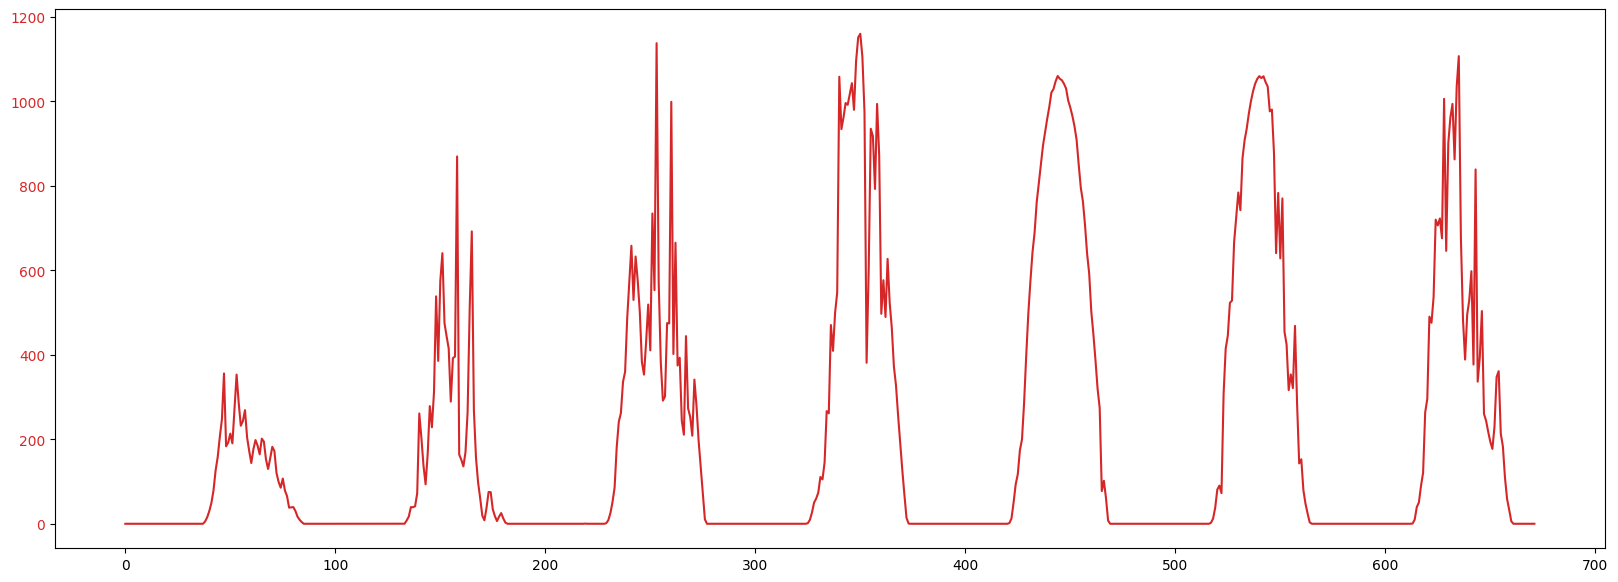

In [23]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Criação da figura com um tamanho um pouco maior para acomodar rótulos
fig, axs = plt.subplots(1, 1, figsize=(20, 7))

# --- PLOT 1: Temperatura e Irradiância ---
# Usar 'tab:red' (vermelho) para temperatura dá um bom contraste
linha1 = axs.plot(conversor.PVirrad, color='tab:red', linestyle='-')

axs.tick_params(axis='y', labelcolor='tab:red')


In [ ]:
# Pega todos os valores da segunda coluna e divide por 1000
valores = (irrad[irrad.columns[1]].values) / 1000

# Formata cada valor com 10 casas decimais, substituindo NaN por 0
valores_formatados = [
    "0.0" if pd.isna(v) or v == 0.0 else f"{v:.16f}"
    for v in valores
]

# Quantidade total de pontos
npts = len(valores_formatados)

# Cria a string no formato DSS
conteudo_dss = f"New LoadShape.MyShapePV1 npts={npts} minterval=1 mult=({', '.join(valores_formatados)})\n"

# Salva como arquivo .dss
nome_arquivo = "src/data/13Bus/LoadShapePV_2.dss"
with open(nome_arquivo, "w") as f:
    f.write(conteudo_dss)

print(f"Processamento concluído! {npts} pontos foram escritos no arquivo.")